Step 1/5  Preprocessing (dewow + median + gain)…
Step 2/5  Edge detection…
Step 3/5  Thresholding…
Step 4/5  C3 clustering…
          Found 2 candidate cluster(s) (after discarding clusters < 20 pts).
Step 5/5  Hyperbola fitting…
          Cluster 1: R²=0.561  ✗ below r2_min=0.75
          Cluster 2: R²=0.807  ✓ accepted

Done.  1 hyperbola(s) fitted successfully.


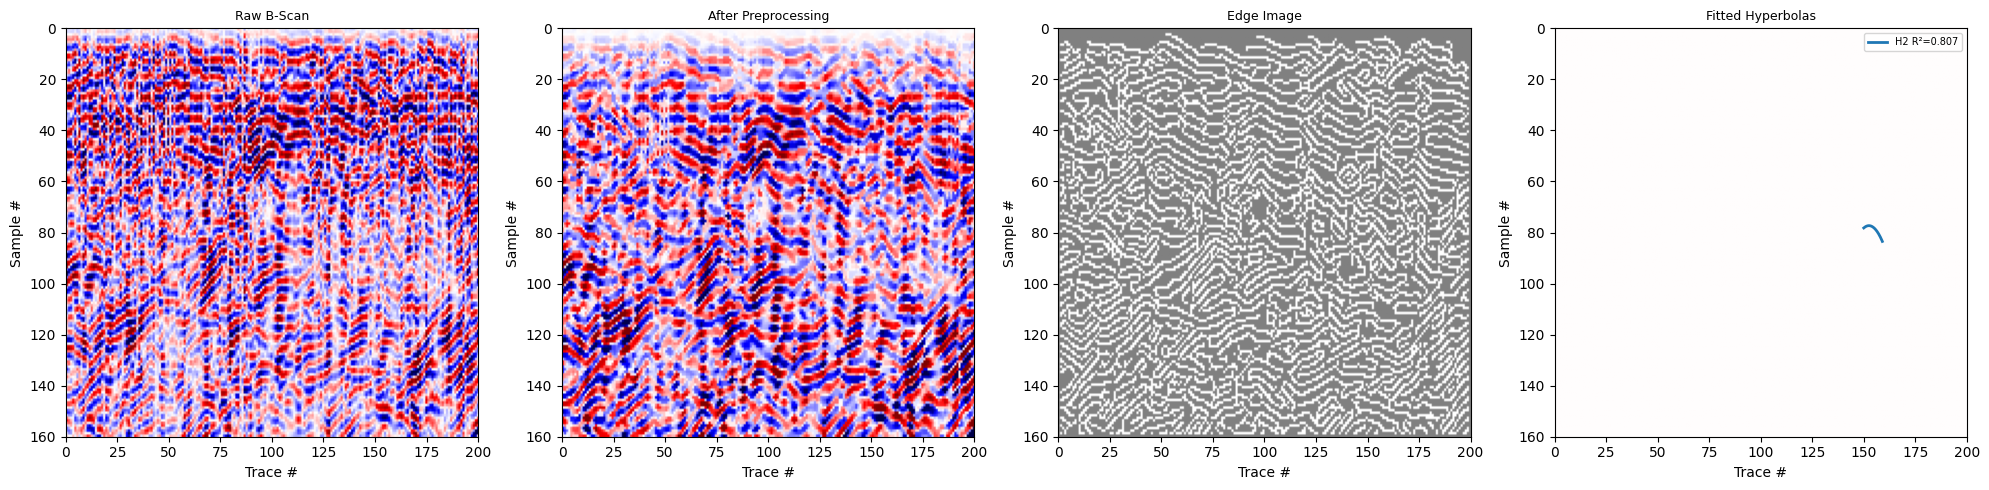

In [18]:
import numpy as np
from gpr_hyperbola_detection import detect_hyperbolas

bscan = np.load("/Users/coltenrodriguez/Desktop/GPR-modeling/SimulatingGPR/my_file.npy")  # shape: (n_samples, n_traces)
results, detector = detect_hyperbolas(bscan)
detector.plot(results)

In [37]:
import numpy as np
from gpr_hyperbola_fit import GPRHyperbolaDetector
import matplotlib.pyplot as plt

bscan = np.load("/Users/coltenrodriguez/Desktop/GPR-modeling/SimulatingGPR/my_file.npy")   # 2-D float array (rows=time, cols=distance)

detector = GPRHyperbolaDetector(
    rho_b=0.1,          # threshold sensitivity (paper's recommended value)
    s=1,                # min column-segment run length
    ncc_threshold=0.3,  # NCC decision boundary
    max_iter=100,       # Gauss-Newton iterations
    min_cols=2,         # discard very narrow clusters
)
results = detector.detect(bscan)
for r in results:
    print(r.a, r.b, r.x0, r.y0)   # hyperbola parameters
    ys = r.evaluate(np.arange(bscan.shape[1]))  # y-coords of fitted curve

1795.9398962452378 93.21369143081328 171.1458906807586 1831.7708549889273


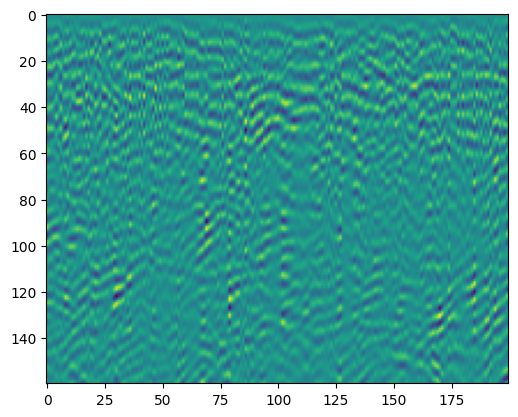

In [38]:
plt.imshow(bscan)
for r in results[:-1]:
    ys = r.evaluate(np.arange(bscan.shape[1]))  # y-coords of fitted curve
    # Physical constants
    C_LIGHT = 0.2998  # speed of light in m/ns
    
    # Calibration (user-supplied)
    dx = 0.5   # metres per pixel  (horizontal)
    dy = 2.5     # nanoseconds per pixel (vertical / time axis)
    
    # From a fitted hyperbola result r:
    a = r.a   # semi-major axis in pixels
    b = r.b   # semi-minor axis in pixels
    
    # Propagation velocity in the medium (m/ns)
    # Derived from the hyperbola geometry: v = 2 * (b*dx) / (a*dy)
    # Factor of 2 accounts for two-way travel time
    v = (b * dx) / (a * dy)
    
    # Relative permittivity
    eps_r = (C_LIGHT / v) ** 2
    
    # Depth to the scatterer apex (m)
    # The apex pixel row relative to the surface gives one-way travel time
    # t0 = a * dy  [ns]  (apex is a pixels below y0 in the image)
    t0_ns = a * dy          # two-way travel time at apex in nanoseconds
    depth = (v * t0_ns) / 2 # one-way
    
    print(f"Velocity      : {v:.4f} m/ns  ({v*1e3:.1f} mm/ns)")
    print(f"Rel. permittivity εr : {eps_r:.3f}")
    print(f"Apex two-way time    : {t0_ns:.2f} ns")
    print(f"Estimated depth      : {depth:.3f} m")
    plt.scatter(r.x0, r.y0)

In [79]:
from PIL import Image
from bruges.filters.wavelets import ricker
import migration as mig
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import skimage

radargram = np.load('/Users/coltenrodriguez/Desktop/GPR-modeling/SimulatingGPR/array.npy', allow_pickle=True)[:, :200]

c0 = 3e8
f0 = 5.5e7

velocity = c0/np.sqrt(np.array(Image.open('/Users/coltenrodriguez/Desktop/GPR-modeling/SimulatingGPR/heatmap.png'))[:, :200])
velocity = cv.resize(velocity, (300, 300))


w, _ = ricker(duration=1.5 / f0, dt=2.5e-9, f=f0)
w /= np.max(np.abs(w))

dx = 0.5          # m  (100 m / 200 nodes)
dz = 1.0          # m  (45 m  /  45 nodes)
dt = 2.5e-9       # s  (700 ns / 280 samples)

# Shot positions: 200 shots evenly spaced over 100 m
shot_positions = np.linspace(0, 100 - dx, 200)  # shape (200,), in metres

# Ricker wavelet — dominant frequency ~50 MHz is reasonable for 0.5 m grid
source_wavelet, _ = ricker(duration=1.5 / f0, dt=dt, f=f0)   # shape (n_wavelet,)

image = mig.gpr_rtm(
    radargram       = radargram,        # shape (280, 200)
    shot_positions  = shot_positions,   # shape (200,), metres
    velocity_model  = velocity,   # shape (200, 45), m/s
    dx              = dx,               # 0.5 m
    dz              = dz,               # 1.0 m
    dt              = dt,               # 2.5e-9 s
    source_wavelet  = source_wavelet,
)

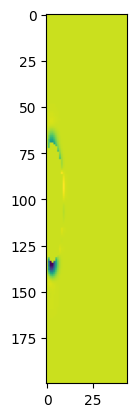

In [80]:
plt.imshow(migrated_image)

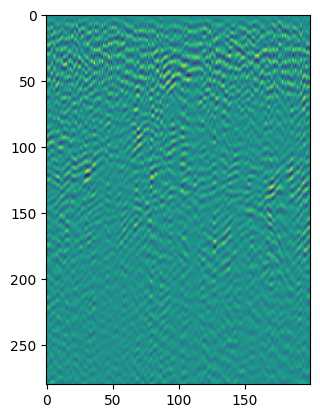

In [53]:
plt.imshow(radargram)